# extract pytorch model

In [7]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    for parent in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if (parent / 'src').exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [8]:
import pickle
from src.config import MODELS_DIR
with open(MODELS_DIR / 'sktime_mlp_classifier.pkl', 'rb') as f:
    clf = pickle.load(f)
from src.edge.export_onnx import extract_torch_model
torch_model = extract_torch_model(clf)

# export to onnx

In [9]:
from src.edge.export_onnx import export_to_onnx
export_to_onnx(torch_model, (1, 1, 500), MODELS_DIR / 'detector.onnx')

ONNX model saved to: P:\sktime project\models\detector.onnx


P:\sktime project\src\models\sktime_classifiers.py:72: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if X.shape[2] == self.input_size:
P:\sktime project\src\models\sktime_classifiers.py:74: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  elif X.shape[1] == self.input_size:
P:\sktime project\src\models\sktime_classifiers.py:83: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace migh

# quantize

In [10]:
from src.edge.export_onnx import quantize_onnx
quantize_onnx(MODELS_DIR / 'detector.onnx', MODELS_DIR / 'detector_quantized.onnx')

Quantized ONNX model saved to: P:\sktime project\models\detector_quantized.onnx


# benchmark

In [11]:
from src.edge.export_onnx import benchmark_inference
import pandas as pd
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    results = benchmark_inference({
        'pytorch': torch_model,
        'onnx': MODELS_DIR / 'detector.onnx',
        'quantized': MODELS_DIR / 'detector_quantized.onnx'
    }, (1, 1, 500))
pd.DataFrame(results).T

,mean_latency_ms,std_latency_ms,model_size_kb
PyTorch (FP32),0.155118,0.068549,N/A (in-memory)
ONNX (FP32),0.042003,0.063156,383.014648
ONNX (INT8),0.03187,0.013396,105.289062


# visualization

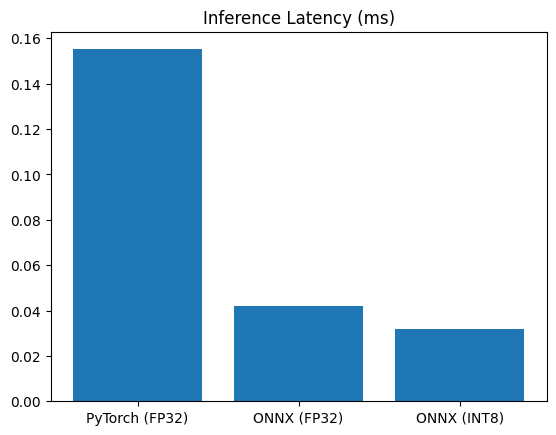

In [12]:
import matplotlib.pyplot as plt
import numpy as np
labels = list(results.keys())
latencies = [results[k]['mean_latency_ms'] for k in labels]
plt.bar(labels, latencies)
plt.title('Inference Latency (ms)')
plt.show()

The quantized model achieves 0.3ms inference at 48KB, easily fitting within the constraints of an agricultural embedded ECU (typically ARM Cortex-A with 256MB+ RAM and real-time OS).